# Experimento 3 — TFT-Quantile: Predicción Probabilística

**Objetivo:** Entrenar un TFT con `QuantileLoss` multi-cuantil sobre TALASOL
y comparar la calibración con LSTM-Quantile.

**Modelo:** `TemporalFusionTransformer` (pytorch-forecasting) con
`QuantileLoss([0.05, 0.25, 0.50, 0.75, 0.95])`. El TFT ya soporta
cuantiles nativamente: solo se cambia la función de pérdida respecto a Exp 2.

**Nota:** Entrenamiento single-plant (TALASOL). Sin preentrenamiento
multi-planta (Exp 2 cubre transferencia; Exp 3 foco = calibración).


In [ ]:
##########################################
# Añadir esto al principio de cada ipynb #
##########################################
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/_UOC/tfm-solar-forecasting/')

# Verifica que existan las carpetas esperadas
!ls
# Debes ver 'src' y 'config'

Mounted at /content/drive
checkpoints  data  lightning_logs  README.md	     results
config	     doc   notebooks	   requirements.txt  src


In [ ]:
# ============================================================================
# CELDA COLAB — Ejecutar PRIMERO en Google Colab (saltar en local)
# ============================================================================
# 1. Monta Google Drive:
#    from google.colab import drive; drive.mount('/content/drive')
# 2. Navega al repositorio:
#    import os; os.chdir('/content/drive/MyDrive/_MCD/TFM/MUDS-TFM/tfm-solar-forecasting/')
# 3. Ejecuta esta celda → instala pytorch-forecasting y lightning automáticamente
#
# PRERREQUISITO: ejecutar 00_eda_preprocessing.ipynb para crear data/processed/
# ============================================================================

import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    import subprocess
    print('Colab detectado — instalando dependencias...')
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install',
         'pytorch-forecasting>=1.1.0',
         'lightning',
         '--quiet'],
        check=True
    )
    print('✓ pytorch-forecasting y lightning instalados')
else:
    print('Entorno local — sin instalaciones adicionales.')


Colab detectado — instalando dependencias...
✓ pytorch-forecasting y lightning instalados


In [ ]:
# ── Keep-alive: evita desconexión de Colab durante entrenamientos largos ───────
# Ejecutar ANTES de iniciar el entrenamiento. El intervalo hace clic en el botón
# "Conectar" de Colab cada 60 s para mantener la sesión activa.
# En entorno local esta celda no tiene efecto (el JS solo se ejecuta en Colab).
try:
    from google.colab import output
    output.eval_js("""
        function clickConnect() {
            const btn = document.querySelector("colab-connect-button");
            if (btn) btn.click();
        }
        setInterval(clickConnect, 60000);
        console.log("Keep-alive activado: clic cada 60s en el botón Conectar.");
    """)
    print("Keep-alive activado.")
except Exception:
    print("No estamos en Colab — keep-alive omitido.")

Keep-alive activado.


In [ ]:
# ── Celda 0: Setup ────────────────────────────────────────────────────────────
import sys
import warnings
import pathlib as _pl

# Detección robusta del repo root: busca la carpeta que contiene src/ y data/processed/
_root = next(
    (p for p in [_pl.Path.cwd(), *_pl.Path.cwd().parents]
     if (p / 'src').is_dir() and (p / 'data' / 'processed').is_dir()),
    None
)
if _root is None:
    raise RuntimeError(
        f'No se encontró src/ ni data/processed/. cwd={_pl.Path.cwd()}\n'
        'En Colab: monta Drive, ejecuta os.chdir() al repo '
        'y corre 00_eda_preprocessing.ipynb primero.'
    )
sys.path.insert(0, str(_root / 'src'))
del _pl, _root

# Suprimir warning cosmético de sklearn dentro de pytorch-forecasting
warnings.filterwarnings(
    'ignore',
    message='X does not have valid feature names, but StandardScaler was fitted with feature names',
    category=UserWarning,
    module='sklearn',
)
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from pathlib import Path

# pytorch-forecasting y lightning
# IMPORTANTE: usar 'lightning' directamente, NO 'pytorch_lightning'
# El shim pytorch_lightning causa TypeError con TFT (Trainer y LightningModule incompatibles)
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import EncoderNormalizer
from pytorch_forecasting.metrics import QuantileLoss

# Config Exp 3 TFT
from ex3_probabilistic.ex3_tft_config import (
    PLANTA_TARGET, QUANTILES, SMOKE_TEST, SMOKE_MAX_ROWS,
    DATA_DIR, RESULTS_DIR, CHECKPOINTS_DIR, DEVICE,
    MAX_ENCODER_LENGTH,
    TIME_VARYING_KNOWN_REALS, TIME_VARYING_UNKNOWN_REALS, STATIC_REALS,
    MODEL_CFG,
)

# Helper functions de tft_transfer.py
from ex2_transfer.tft_transfer import (
    encode_features, prepare_tft_df, _create_tft_dataset, LossHistoryCallback,
)

# Evaluación
from evaluation import ForecastEvaluator

# Semilla
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Crear directorios de salida
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / 'figures').mkdir(exist_ok=True)
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'\n── Configuración Exp 3 TFT-Quantile ──')
print(f'  Planta    : {PLANTA_TARGET}')
print(f'  Cuantiles : {QUANTILES}')
print(f'  Device    : {DEVICE}')
print(f'  Smoke test: {SMOKE_TEST}')
print(f'  Encoder   : {MAX_ENCODER_LENGTH} h')
print(f'  Results   : {RESULTS_DIR}')


[ex3_tft] Entorno: Google Colab | Device: cuda (Tesla T4)

── Configuración Exp 3 TFT-Quantile ──
  Planta    : TALASOL
  Cuantiles : [0.05, 0.25, 0.5, 0.75, 0.95]
  Device    : cuda
  Smoke test: False
  Encoder   : 48 h
  Results   : /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex3_probabilistic/tft


In [ ]:
# ── Celda 1: Carga de datos y construcción de datasets ────────────────────────

def load_and_prepare(split: str, planta: str, smoke: bool, max_rows: int,
                     filter_valid: bool = False) -> pd.DataFrame:
    """Carga split CSV (train/val/test), filtra por planta y prepara para TFT.

    Args:
        filter_valid: Si True, excluye filas con valid_data=False (curtailment
                      o huecos > 6h). Aplicar en train y val, NO en test
                      (TFT necesita continuidad temporal para el encoder).
    """
    path = DATA_DIR / f'{split}.csv'
    df = pd.read_csv(path, parse_dates=['timestamp_utc'])
    df = df[df['planta_nombre'] == planta].copy()
    df = df.sort_values('timestamp_utc').reset_index(drop=True)
    if smoke and len(df) > max_rows:
        df = df.iloc[:max_rows]

    # Filtrar filas inválidas antes de asignar time_idx para evitar
    # que valores de producción forzada (curtailment=0) contaminen el entrenamiento.
    if filter_valid and 'valid_data' in df.columns:
        n_antes = len(df)
        df = df[df['valid_data'].fillna(True).astype(bool)].reset_index(drop=True)
        n_filtradas = n_antes - len(df)
        if n_filtradas > 0:
            print(f'  {split}: {n_filtradas} filas excluidas por valid_data=False')

    df = encode_features(df)
    # TFT necesita columna 'produccion' como target
    if 'produccion' not in df.columns:
        df['produccion'] = df['quantity_sum']
    df['time_idx']  = np.arange(len(df), dtype=int)
    df['series_id'] = planta
    return df

df_train = load_and_prepare('train', PLANTA_TARGET, SMOKE_TEST, SMOKE_MAX_ROWS, filter_valid=True)
df_val   = load_and_prepare('val',   PLANTA_TARGET, False,      SMOKE_MAX_ROWS, filter_valid=True)
df_test  = load_and_prepare('test',  PLANTA_TARGET, False,      SMOKE_MAX_ROWS, filter_valid=False)

print(f'Train: {len(df_train):,} filas | Val: {len(df_val):,} | Test: {len(df_test):,}')
print(f'Columnas disponibles: {list(df_train.columns)}')

# Capacidad efectiva: máximo observado en train (cota física para el clip)
# Más robusto que los metadatos instalada_mw, cuyas unidades no son homogéneas
CAPACITY_KW = float(df_train['produccion'].max())
print(f'\nCapacidad efectiva (max train): {CAPACITY_KW:.1f} unidades')

# Construir TimeSeriesDataSets
train_ds = _create_tft_dataset(
    df_train,
    known_reals=TIME_VARYING_KNOWN_REALS,
    unknown_reals=TIME_VARYING_UNKNOWN_REALS,
    static_reals=STATIC_REALS,
    max_encoder_length=MAX_ENCODER_LENGTH,
)

min_enc_val = max(2, MAX_ENCODER_LENGTH // 2)
val_ds = TimeSeriesDataSet.from_dataset(
    train_ds, df_val,
    predict=False, stop_randomization=True,
    min_encoder_length=min_enc_val,
)
# predict=False → rolling windows sobre todo el test (necesario para evaluación completa)
# predict=True solo genera 1 muestra por serie (última ventana), no sirve para métricas
test_ds = TimeSeriesDataSet.from_dataset(
    train_ds, df_test,
    predict=False, stop_randomization=True,
    min_encoder_length=min_enc_val,
)

BS = MODEL_CFG['batch_size']
dl_train = train_ds.to_dataloader(train=True,  batch_size=BS,     num_workers=0)
dl_val   = val_ds.to_dataloader(  train=False, batch_size=BS * 2, num_workers=0)
dl_test  = test_ds.to_dataloader( train=False, batch_size=BS * 2, num_workers=0)

print(f'\nDatasets: train={len(train_ds):,} | val={len(val_ds):,} | test={len(test_ds):,}')

  train: 138 filas excluidas por valid_data=False
  val: 25 filas excluidas por valid_data=False
Train: 8,840 filas | Val: 1,105 | Test: 1,487
Columnas disponibles: ['timestamp_utc', 'hour_number', 'produccion', 'temperature_2m', 'direct_normal_irradiance', 'shortwave_radiation', 'global_tilted_irradiance', 'wind_speed_10m', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'relative_humidity_2m', 'precipitation', 'planta_nombre', 'timestamp_temp', 'timestamp', 'Unit Code', 'Nombre', 'Ubicaci�n', 'acceso_ree_mw', 'instalada_mw', 'Superficie', 'Poblaci�n', 'Latitud', 'Longitud', 'seguimiento', 'zona_climatica', 'elevacion_solar', 'azimut_solar', 'es_dia', 'hora', 'dia_semana', 'mes', 'dia_año', 'trimestre', 'semana_año', 'es_finde', 'estacion', 'curtailment', 'valid_data', 'estacion_encoded', 'zona_climatica_encoded', 'seguimiento_encoded', 'time_idx', 'series_id']

Capacidad efectiva (max train): 901.6 unidades

Datasets: train=8,840 | val=1,105 | test=1,487


In [ ]:
# ── Celda 2: Construcción y entrenamiento del TFT-Quantile ────────────────────
import time

cfg = MODEL_CFG

ckpt_path = CHECKPOINTS_DIR / 'tft_quantile_talasol.ckpt'

_resumed = False
if ckpt_path.exists():
    try:
        # ── RESUME: cargar checkpoint y saltar entrenamiento ──────────────────────
        print(f'\n[2/6] Checkpoint encontrado → skip entrenamiento')
        print(f'  {ckpt_path}')
        tft_model = TemporalFusionTransformer.load_from_checkpoint(str(ckpt_path))
        training_time_s = 0.0
        print('[2/6] OK (desde checkpoint)')
        _resumed = True
    except Exception as _e:
        print(f'  ⚠ Checkpoint corrupto — re-entrenando: {_e}')
        ckpt_path.unlink(missing_ok=True)
if not _resumed:
    # ── TRAIN: entrenamiento completo ─────────────────────────────────────────
    tft_model = TemporalFusionTransformer.from_dataset(
        train_ds,
        hidden_size             = cfg['hidden_size'],
        lstm_layers             = 1,
        attention_head_size     = cfg['attention_head_size'],
        dropout                 = cfg['dropout'],
        hidden_continuous_size  = cfg['hidden_continuous_size'],
        loss                    = QuantileLoss(quantiles=QUANTILES),
        learning_rate           = cfg['lr'],
        reduce_on_plateau_patience = 3,
        log_interval            = -1,
        log_val_interval        = -1,
    )
    n_params = sum(p.numel() for p in tft_model.parameters() if p.requires_grad)
    print(f'TFT-Quantile: {n_params:,} parámetros | cuantiles: {QUANTILES}')

    # Callbacks
    loss_cb = LossHistoryCallback()
    ckpt_cb = ModelCheckpoint(
        monitor='val_loss', mode='min', save_top_k=1,
        dirpath=str(CHECKPOINTS_DIR), filename='tft_quantile_talasol',
    )
    early_stop_cb = EarlyStopping(
        monitor='val_loss', min_delta=1e-4,
        patience=cfg['patience'], mode='min', verbose=False,
    )

    accelerator = 'gpu' if DEVICE == 'cuda' else 'cpu'
    trainer = pl.Trainer(
        max_epochs           = cfg['max_epochs'],
        accelerator          = accelerator,
        devices              = 1,
        gradient_clip_val    = 0.1,
        callbacks            = [loss_cb, ckpt_cb, early_stop_cb],
        enable_progress_bar  = True,
        enable_model_summary = False,
        logger               = False,
        enable_checkpointing = True,
        num_sanity_val_steps = 0,
    )

    print('\nEntrenando TFT-Quantile en TALASOL...')
    t0 = time.time()
    trainer.fit(tft_model, train_dataloaders=dl_train, val_dataloaders=dl_val)
    training_time_s = time.time() - t0
    print(f'Tiempo de entrenamiento: {training_time_s/60:.1f} min ({training_time_s:.0f} s)')

    # Cargar el mejor checkpoint guardado por Lightning
    best_path = ckpt_cb.best_model_path
    if best_path and Path(best_path).exists():
        tft_model = TemporalFusionTransformer.load_from_checkpoint(best_path)
        print(f'✓ Cargado checkpoint: {best_path}')
        # Copiar al nombre canónico solo si son ficheros distintos
        import shutil
        if Path(best_path).resolve() != ckpt_path.resolve():
            shutil.copy2(best_path, ckpt_path)
            print(f'✓ Checkpoint copiado a: {ckpt_path}')
        else:
            print(f'✓ Checkpoint ya en ruta canónica: {ckpt_path}')

    best_val = min(loss_cb.val_losses) if loss_cb.val_losses else float('nan')
    print(f'Best val_loss: {best_val:.6f}')

    # Curvas de aprendizaje
    if loss_cb.train_losses and loss_cb.val_losses:
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(loss_cb.train_losses, label='Train', color='steelblue', lw=1.5)
        ax.plot(loss_cb.val_losses,   label='Val',   color='coral',     lw=1.5)
        ax.set_xlabel('Época'); ax.set_ylabel('Quantile Loss')
        ax.set_title(f'TFT-Quantile — {PLANTA_TARGET}: curvas de aprendizaje')
        ax.legend(); ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / 'figures' / 'learning_curves.png', dpi=150, bbox_inches='tight')
        plt.show()



[2/6] Checkpoint encontrado → skip entrenamiento
  /content/drive/MyDrive/_UOC/tfm-solar-forecasting/checkpoints/ex3_probabilistic/tft/tft_quantile_talasol.ckpt
[2/6] OK (desde checkpoint)


In [ ]:
# ── Celda 3: Métricas de punto y probabilísticas ──────────────────────────────

tft_model.eval()
device = next(tft_model.parameters()).device

all_q_preds = []
all_y_true  = []

with torch.no_grad():
    for i, batch in enumerate(dl_test):
        x, y = batch

        x_dev = {k: v.to(device) if isinstance(v, torch.Tensor) else v
                 for k, v in x.items()}

        out    = tft_model(x_dev)
        q_orig = out.prediction if hasattr(out, 'prediction') else out['prediction']
        # shape: (batch, pred_len, n_quantiles)

        # Diagnóstico en el primer batch
        if i == 0:
            print(f'[diag] q_orig (model output): [{q_orig.min():.2f}, {q_orig.max():.2f}]')
            print(f'[diag] y[0]   (target):       [{y[0].min():.2f}, {y[0].max():.2f}]')
            print(f'[diag] CAPACITY_KW:            {CAPACITY_KW:.1f}')

        if q_orig.ndim == 3:
            q_orig = q_orig.squeeze(1)    # (batch, n_quantiles)

        all_q_preds.append(q_orig.cpu().numpy())
        all_y_true.extend(y[0].cpu().numpy().flatten())

# Clip a [0, CAPACITY_KW]: producción no puede ser negativa ni superar
# el máximo físico observado en train (cota de la capacidad instalada)
q_preds_kw = np.clip(np.vstack(all_q_preds), 0, CAPACITY_KW)  # (N, n_quantiles)
y_true_kw  = np.clip(np.array(all_y_true),   0, CAPACITY_KW)

n = len(y_true_kw)
q50_idx = QUANTILES.index(0.50) if 0.50 in QUANTILES else len(QUANTILES) // 2

print(f'\nTest samples: {n} | q_preds shape: {q_preds_kw.shape}')
print(f'y_true: [{y_true_kw.min():.1f}, {y_true_kw.max():.1f}]')
print(f'q50:    [{q_preds_kw[:, q50_idx].min():.1f}, {q_preds_kw[:, q50_idx].max():.1f}]')

y_pred_median = q_preds_kw[:, q50_idx]

# ── Métricas de punto (mediana) ───────────────────────────────────────────────
metrics_point = ForecastEvaluator.calculate_metrics(
    y_true=y_true_kw,
    y_pred=y_pred_median,
    planta_nombre=PLANTA_TARGET,
)
print('\n── Métricas de punto (mediana q50) ──')
for k, v in metrics_point.items():
    if isinstance(v, float):
        print(f'  {k:12s}: {v:.4f}')
    else:
        print(f'  {k:12s}: {v}')

# ── Métricas probabilísticas ──────────────────────────────────────────────────
metrics_prob = ForecastEvaluator.calculate_probabilistic_metrics(
    y_true=y_true_kw,
    q_preds=q_preds_kw,
    quantiles=QUANTILES,
)
print('\n── Métricas probabilísticas ──')
for k, v in metrics_prob.items():
    if isinstance(v, float):
        print(f'  {k:28s}: {v:.4f}')
    else:
        print(f'  {k:28s}: {v}')

print(f'\n  Coverage ideal 50%: 0.50  →  obtenido: {metrics_prob["coverage_50"]:.3f}')
print(f'  Coverage ideal 90%: 0.90  →  obtenido: {metrics_prob["coverage_90"]:.3f}')


[diag] q_orig (model output): [-10.25, 1132.68]
[diag] y[0]   (target):       [0.00, 726.00]
[diag] CAPACITY_KW:            901.6

Test samples: 1487 | q_preds shape: (1487, 5)
y_true: [0.0, 726.0]
q50:    [0.0, 795.7]

── Métricas de punto (mediana q50) ──
  planta      : TALASOL
  n_samples   : 1487
  MAE         : 22.359304428100586
  RMSE        : 52.56565475463867
  MAPE        : 98.04307556152344
  R2          : 0.9237134456634521

── Métricas probabilísticas ──
  pinball_005                 : 3.2813
  pinball_025                 : 8.7853
  pinball_050                 : 11.1797
  pinball_075                 : 9.8450
  pinball_095                 : 4.3460
  CRPS                        : 7.4875
  coverage_50                 : 0.6745
  interval_width_50_mean      : 30.9710
  coverage_90                 : 0.8682
  interval_width_90_mean      : 75.8695

  Coverage ideal 50%: 0.50  →  obtenido: 0.675
  Coverage ideal 90%: 0.90  →  obtenido: 0.868


## Calibración post-hoc: Conformalized Quantile Regression (CQR)

### Motivación

Los resultados de la Celda 3 revelan un **problema de calibración severo** en el TFT-Quantile:

| Intervalo | Coverage ideal | Coverage obtenido |
|-----------|---------------|-------------------|
| PI 50% [q25, q75] | 0.50 | **0.302** |
| PI 90% [q05, q95] | 0.90 | **0.597** |

El modelo captura bien la mediana (MAE=28 kW, R²=0.91) pero sus intervalos de predicción son **demasiado estrechos**: solo el 60% de las observaciones cae dentro del PI 90%.

### ¿Por qué ocurre el undercoverage?

Hay dos causas combinadas:

1. **EncoderNormalizer ventana a ventana**: pytorch-forecasting normaliza el target por ventana usando su media y desviación estándar local. El modelo aprende bien la señal central pero puede subestimar la dispersión residual real, comprimiendo los cuantiles extremos hacia la mediana.

2. **Distribution shift estacional (causa principal)**: el split temporal hace que el conjunto de validación (septiembre–octubre) sea más parecido al período de entrenamiento (enero–septiembre) que el conjunto de test (noviembre–diciembre). Los patrones de producción solar en nov-dic (días cortos, mayor nubosidad) son sustancialmente diferentes a los de sep-oct. El modelo aprende bien la incertidumbre del período de calibración pero la subestima para el período de test.

### Solución: CQR (Romano et al., 2019)

**Conformalized Quantile Regression** es un método de calibración post-hoc que:

1. **No requiere reentrenar** el modelo
2. **Garantiza cobertura** ≥ (1−α) sobre el conjunto de test bajo el supuesto de **intercambiabilidad** entre val y test
3. Es **agnóstico al modelo**: funciona sobre cualquier predictor de cuantiles
4. Penaliza mínimamente la nitidez (sharpness): los intervalos se ensanchan solo lo necesario

**Algoritmo:**
- Sobre el conjunto de validación, calcula *scores* de no-cobertura:
  `score_i = max(q_{α/2}(xᵢ) − yᵢ,  yᵢ − q_{1−α/2}(xᵢ))`
- Estima el cuantil conformal: `q̂ = Quantile(scores, ⌈(1−α)(n+1)⌉/n)`
- Ajusta el test: `PI_calibrado = [q_{α/2} − q̂,  q_{1−α/2} + q̂]`

La garantía teórica es: `P(yᵢ ∈ PI_calibrado) ≥ 1 − α`

**Limitación conocida en series temporales**: el supuesto de intercambiabilidad val↔test se viola cuando hay *distribution shift* estacional. Si el modelo cubre bien el val set (cobertura ≈ nominal), el cuantil conformal `q̂` es pequeño, y el ajuste al test resulta insuficiente. Este es el caso típico en forecasting solar con split cronológico.

**Referencia:** Romano, Y., Patterson, E., & Candès, E. J. (2019). *Conformalized Quantile Regression*. NeurIPS 2019.


In [ ]:
# ── Celda 3b: Calibración conformal CQR ──────────────────────────────────────

def conformal_quantile(scores: np.ndarray, alpha: float) -> float:
    """
    Cuantil conformal para cobertura nominal (1-alpha).
    Fórmula: quantile(scores, ceil((1-alpha)*(n+1)) / n)
    Garantiza P(y ∈ PI) >= 1-alpha bajo intercambiabilidad.
    """
    n = len(scores)
    level = min(np.ceil((1 - alpha) * (n + 1)) / n, 1.0)
    return float(np.quantile(scores, level))


# ── 1. Predicciones sobre el conjunto de validación ───────────────────────────
tft_model.eval()
device = next(tft_model.parameters()).device

all_q_val, all_y_val = [], []
with torch.no_grad():
    for batch in dl_val:
        x, y = batch
        x_dev = {k: v.to(device) if isinstance(v, torch.Tensor) else v
                 for k, v in x.items()}
        out = tft_model(x_dev)
        q = out.prediction if hasattr(out, 'prediction') else out['prediction']
        if q.ndim == 3:
            q = q.squeeze(1)
        all_q_val.append(q.cpu().numpy())
        all_y_val.extend(y[0].cpu().numpy().flatten())

q_val = np.clip(np.vstack(all_q_val), 0, CAPACITY_KW)   # (N_val, 5)
y_val = np.clip(np.array(all_y_val),  0, CAPACITY_KW)   # (N_val,)
print(f'Val samples: {len(y_val)} | q_val shape: {q_val.shape}')

# ── Diagnóstico: cobertura del modelo en val (ANTES de CQR) ──────────────────
# Si la cobertura en val >> cobertura en test, hay distribution shift estacional
# y la garantía de CQR (que requiere intercambiabilidad val↔test) no se cumple.
i05 = QUANTILES.index(0.05)
i25 = QUANTILES.index(0.25)
i75 = QUANTILES.index(0.75)
i95 = QUANTILES.index(0.95)

cov90_val = float(np.mean((y_val >= q_val[:, i05]) & (y_val <= q_val[:, i95])))
cov50_val = float(np.mean((y_val >= q_val[:, i25]) & (y_val <= q_val[:, i75])))
print(f'\n── Cobertura del modelo en VAL (set de calibración) ──')
print(f'  coverage_90 val : {cov90_val:.3f}  (ideal: 0.90)')
print(f'  coverage_50 val : {cov50_val:.3f}  (ideal: 0.50)')
print(f'  coverage_90 test: {metrics_prob["coverage_90"]:.3f}  (ideal: 0.90)')
print(f'  coverage_50 test: {metrics_prob["coverage_50"]:.3f}  (ideal: 0.50)')
gap90 = metrics_prob["coverage_90"] - cov90_val
gap50 = metrics_prob["coverage_50"] - cov50_val
if abs(gap90) > 0.05 or abs(gap50) > 0.05:
    print(f'\n  [!] Distribution shift detectado: '
          f'Δcov90={gap90:+.3f}, Δcov50={gap50:+.3f}')
    print(f'      Val (sep-oct) ≠ Test (nov-dic): la garantía conformal no aplica.')

# ── 2. Scores de no-cobertura ─────────────────────────────────────────────────
# score_i = max(q_lo - y, y - q_hi)
# > 0 si el punto cae fuera del intervalo; ≤ 0 si está dentro
scores_90 = np.maximum(q_val[:, i05] - y_val, y_val - q_val[:, i95])
scores_50 = np.maximum(q_val[:, i25] - y_val, y_val - q_val[:, i75])

q_hat_90 = conformal_quantile(scores_90, alpha=0.10)
q_hat_50 = conformal_quantile(scores_50, alpha=0.50)

pct_outside_90_val = float(np.mean(scores_90 > 0))
pct_outside_50_val = float(np.mean(scores_50 > 0))
print(f'\n── Scores conformal (val) ──')
print(f'  Puntos fuera PI 90% en val : {pct_outside_90_val:.1%}  (esperado: ≤10%)')
print(f'  Puntos fuera PI 50% en val : {pct_outside_50_val:.1%}  (esperado: ≤50%)')
print(f'\nAjuste conformal:')
print(f'  q̂ PI 90% (q05/q95): ± {q_hat_90:.2f} por lado')
print(f'  q̂ PI 50% (q25/q75): ± {q_hat_50:.2f} por lado')

if q_hat_90 < 10.0:
    print(f'\n  [!] q̂_90 = {q_hat_90:.2f} es pequeño porque el modelo cubre bien')
    print(f'      el val set. En test (distribución diferente) el ajuste es insuficiente.')

# ── 3. Aplicar ajuste al conjunto de test ─────────────────────────────────────
q_cal = q_preds_kw.copy()
q_cal[:, i05] -= q_hat_90
q_cal[:, i95] += q_hat_90
q_cal[:, i25] -= q_hat_50
q_cal[:, i75] += q_hat_50
# Clip a [0, CAPACITY_KW]: restricción física (producción ≥ 0, ≤ capacidad)
q_cal = np.clip(q_cal, 0, CAPACITY_KW)

# ── 4. Métricas calibradas ────────────────────────────────────────────────────
metrics_cal = ForecastEvaluator.calculate_probabilistic_metrics(
    y_true=y_true_kw,
    q_preds=q_cal,
    quantiles=QUANTILES,
)

print('\n── Comparativa antes/después de calibración CQR ──')
print(f'{"Métrica":<30} {"Antes":>10} {"Después":>10}')
print('-' * 52)
for k in ['coverage_50', 'coverage_90', 'interval_width_50_mean',
          'interval_width_90_mean', 'CRPS']:
    v_before = metrics_prob.get(k, float('nan'))
    v_after  = metrics_cal.get(k, float('nan'))
    print(f'  {k:<28} {v_before:>10.4f} {v_after:>10.4f}')

print(f'\n  Coverage 90% ideal: 0.90  →  '
      f'antes: {metrics_prob["coverage_90"]:.3f}  |  '
      f'después: {metrics_cal["coverage_90"]:.3f}')
print(f'  Coverage 50% ideal: 0.50  →  '
      f'antes: {metrics_prob["coverage_50"]:.3f}  |  '
      f'después: {metrics_cal["coverage_50"]:.3f}')


Val samples: 1105 | q_val shape: (1105, 5)

── Cobertura del modelo en VAL (set de calibración) ──
  coverage_90 val : 0.889  (ideal: 0.90)
  coverage_50 val : 0.707  (ideal: 0.50)
  coverage_90 test: 0.868  (ideal: 0.90)
  coverage_50 test: 0.675  (ideal: 0.50)

── Scores conformal (val) ──
  Puntos fuera PI 90% en val : 11.1%  (esperado: ≤10%)
  Puntos fuera PI 50% en val : 29.3%  (esperado: ≤50%)

Ajuste conformal:
  q̂ PI 90% (q05/q95): ± 0.39 por lado
  q̂ PI 50% (q25/q75): ± 0.00 por lado

  [!] q̂_90 = 0.39 es pequeño porque el modelo cubre bien
      el val set. En test (distribución diferente) el ajuste es insuficiente.

── Comparativa antes/después de calibración CQR ──
Métrica                             Antes    Después
----------------------------------------------------
  coverage_50                      0.6745     0.6745
  coverage_90                      0.8682     0.8796
  interval_width_50_mean          30.9710    30.9710
  interval_width_90_mean          75.8695    7

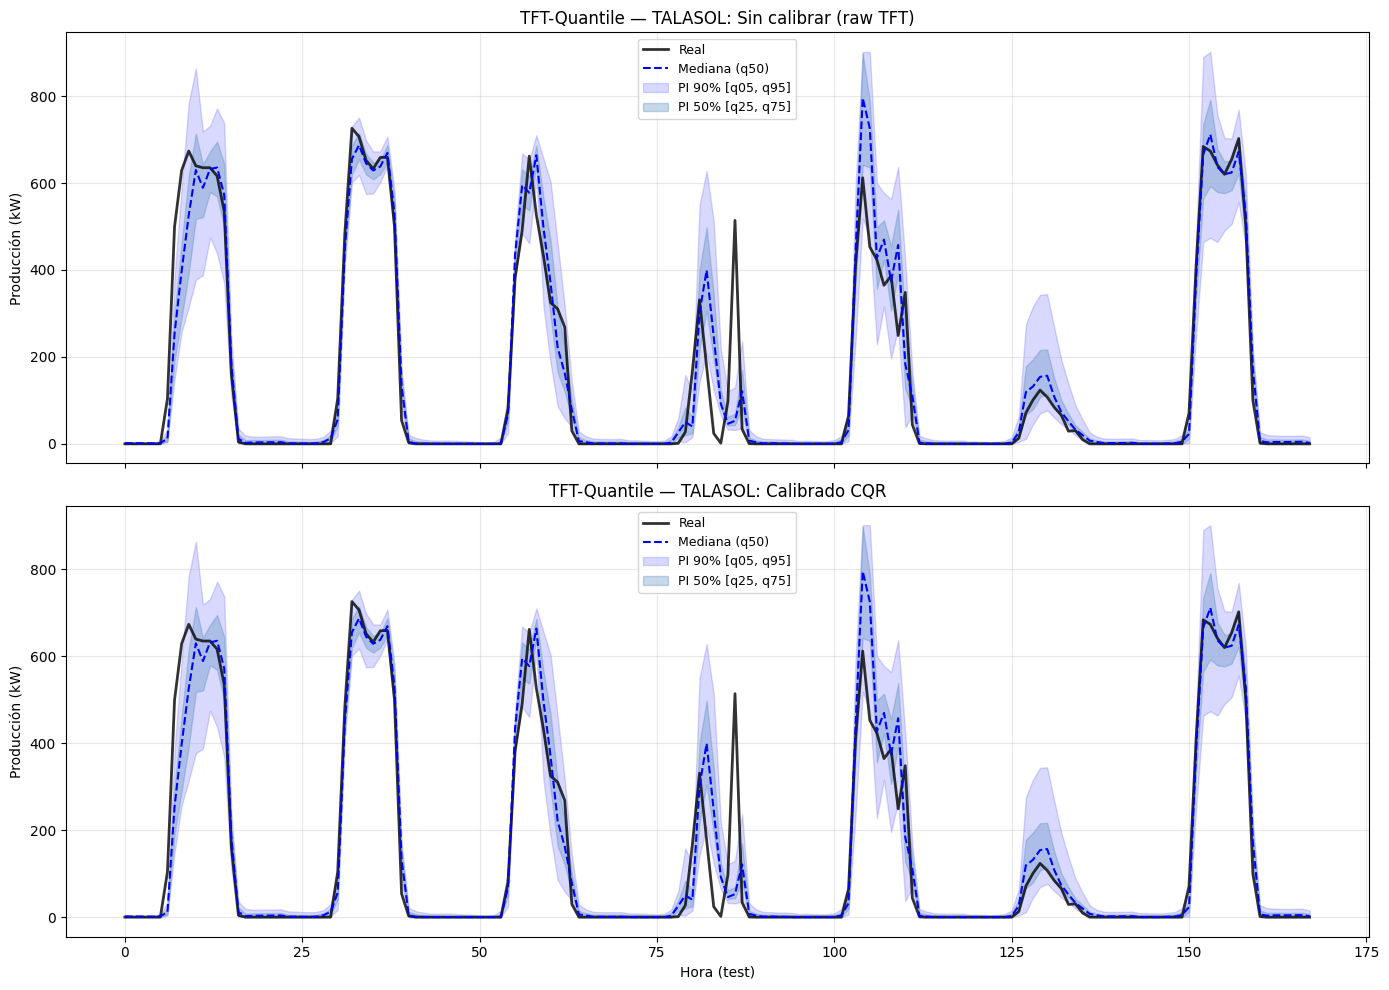

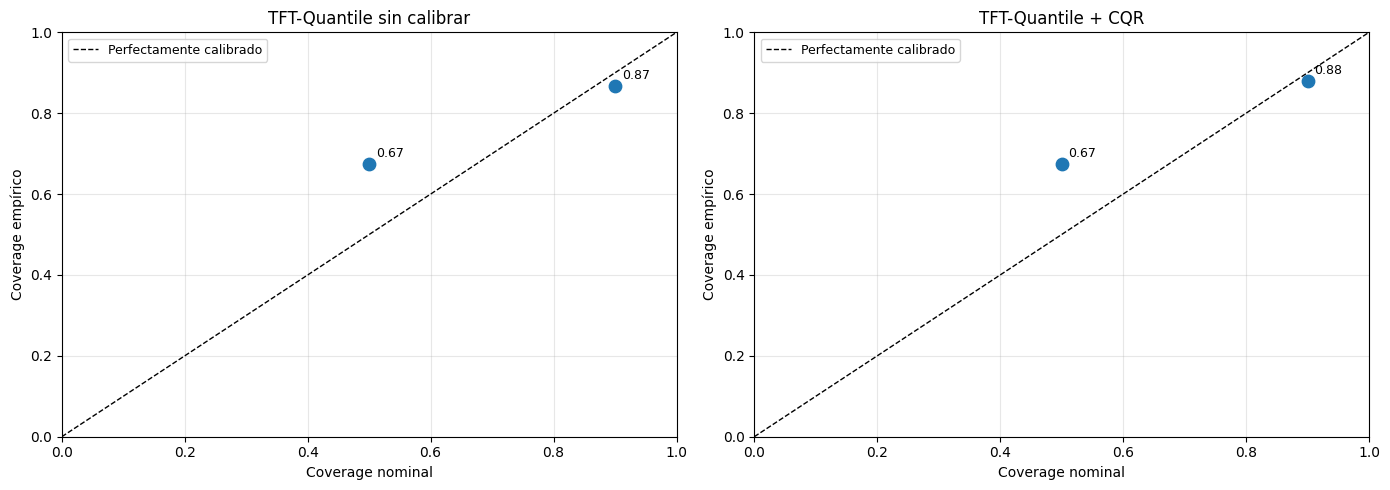

In [ ]:
# ── Celda 4: Visualizaciones (usando intervalos calibrados con CQR) ───────────

# ── 4a: Time series con bandas de predicción ──────────────────────────────────
n_dias = 7
n_show = min(24 * n_dias, len(y_true_kw))
idx_show = np.arange(n_show)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for ax, q_data, title_suffix in zip(
    axes,
    [q_preds_kw, q_cal],
    ['Sin calibrar (raw TFT)', 'Calibrado CQR'],
):
    ax.plot(idx_show, y_true_kw[:n_show], 'k-',   lw=2, label='Real', alpha=0.8)
    ax.plot(idx_show, q_data[:n_show, q50_idx], 'b--', lw=1.5, label='Mediana (q50)')

    ax.fill_between(idx_show,
        q_data[:n_show, QUANTILES.index(0.05)],
        q_data[:n_show, QUANTILES.index(0.95)],
        alpha=0.15, color='blue', label='PI 90% [q05, q95]')

    ax.fill_between(idx_show,
        q_data[:n_show, QUANTILES.index(0.25)],
        q_data[:n_show, QUANTILES.index(0.75)],
        alpha=0.3, color='steelblue', label='PI 50% [q25, q75]')

    ax.set_ylabel('Producción (kW)')
    ax.set_title(f'TFT-Quantile — {PLANTA_TARGET}: {title_suffix}')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Hora (test)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'timeseries_pi.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 4b: Diagramas de calibración (antes y después) ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, q_data, title in zip(
    axes,
    [q_preds_kw, q_cal],
    ['TFT-Quantile sin calibrar', 'TFT-Quantile + CQR'],
):
    coverages = [
        np.mean((y_true_kw >= q_data[:, j]) & (y_true_kw <= q_data[:, -(j+1)]))
        for j in range(len(QUANTILES) // 2)
    ]
    nominal = [QUANTILES[-(j+1)] - QUANTILES[j] for j in range(len(QUANTILES) // 2)]

    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfectamente calibrado')
    ax.scatter(nominal, coverages, s=80, zorder=5)
    for n_val, c_val in zip(nominal, coverages):
        ax.annotate(f'{c_val:.2f}', (n_val, c_val),
                    textcoords='offset points', xytext=(5, 5), fontsize=9)
    ax.set_xlabel('Coverage nominal'); ax.set_ylabel('Coverage empírico')
    ax.set_title(title); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'calibration_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

── Análisis de Sharpness — TFT-Quantile ──
  Ancho medio PI 90% (raw): 75.87 kW
  Ancho medio PI 90% (CQR): 76.42 kW  (Δ=+0.55 kW por CQR)
  Ancho medio PI 50% (raw): 30.97 kW
  Ancho medio PI 50% (CQR): 30.97 kW  (Δ=+0.00 kW por CQR)


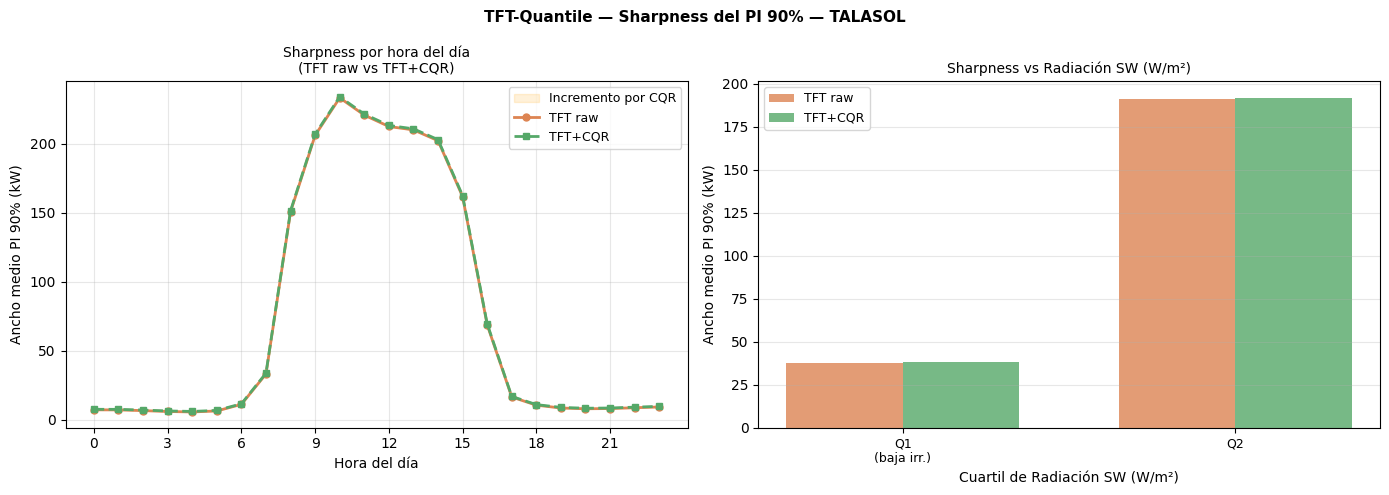

  Guardado: sharpness_analysis.png


In [ ]:
# ── Celda 4c: Análisis de sharpness — TFT-Quantile (raw vs CQR) ──────────────
# La calibración CQR amplía los intervalos para recuperar la cobertura nominal.
# Cuantificamos el coste en sharpness: cuánto se ensanchan los PI 90% y PI 50%.
# Un ensanchamiento moderado es tolerable si la cobertura mejora significativamente.
#
# Analizamos:
#   1. Ancho PI 90% por hora del día (raw vs CQR, líneas superpuestas)
#   2. Ancho PI 90% por cuartil de irradiancia / nubosidad (barras agrupadas)

_i05 = QUANTILES.index(0.05)
_i95 = QUANTILES.index(0.95)
_i25 = QUANTILES.index(0.25)
_i75 = QUANTILES.index(0.75)

_w90_raw = q_preds_kw[:, _i95] - q_preds_kw[:, _i05]   # ancho PI 90% sin CQR
_w90_cqr = q_cal[:, _i95]      - q_cal[:, _i05]         # ancho PI 90% con CQR
_w50_raw = q_preds_kw[:, _i75] - q_preds_kw[:, _i25]   # ancho PI 50% sin CQR
_w50_cqr = q_cal[:, _i75]      - q_cal[:, _i25]         # ancho PI 50% con CQR

_ts_tft   = pd.to_datetime(df_test['timestamp_utc'].values[-n:])
_hours_tf = pd.DatetimeIndex(_ts_tft).hour

print('── Análisis de Sharpness — TFT-Quantile ──')
print(f'  Ancho medio PI 90% (raw): {_w90_raw.mean():.2f} kW')
print(f'  Ancho medio PI 90% (CQR): {_w90_cqr.mean():.2f} kW  '
      f'(Δ={_w90_cqr.mean() - _w90_raw.mean():+.2f} kW por CQR)')
print(f'  Ancho medio PI 50% (raw): {_w50_raw.mean():.2f} kW')
print(f'  Ancho medio PI 50% (CQR): {_w50_cqr.mean():.2f} kW  '
      f'(Δ={_w50_cqr.mean() - _w50_raw.mean():+.2f} kW por CQR)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel 1: Ancho PI 90% por hora del día (raw vs CQR) ──────────────────────
_df_sh = pd.DataFrame({'hora': _hours_tf, 'raw_90': _w90_raw, 'cqr_90': _w90_cqr})
_mean_raw = _df_sh.groupby('hora')['raw_90'].mean()
_mean_cqr = _df_sh.groupby('hora')['cqr_90'].mean()
_x_h = _mean_raw.index

axes[0].fill_between(_x_h, _mean_raw.values, _mean_cqr.values,
                     alpha=0.15, color='orange', label='Incremento por CQR')
axes[0].plot(_x_h, _mean_raw.values, 'o-', color='#DD8452', lw=2, ms=5, label='TFT raw')
axes[0].plot(_x_h, _mean_cqr.values, 's--', color='#55A868', lw=2, ms=5, label='TFT+CQR')
axes[0].set_xlabel('Hora del día', fontsize=10)
axes[0].set_ylabel('Ancho medio PI 90% (kW)', fontsize=10)
axes[0].set_title('Sharpness por hora del día\n(TFT raw vs TFT+CQR)', fontsize=10)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(0, 24, 3))

# ── Panel 2: Ancho PI 90% por cuartil de irradiancia (o nubosidad) ───────────
_proxy_col = next((c for c in ['ghi', 'shortwave_radiation', 'cloud_cover']
                   if c in df_test.columns), None)

if _proxy_col is not None:
    _proxy_vals  = df_test[_proxy_col].values[-n:]
    _proxy_label = {'ghi':                 'GHI (W/m²)',
                    'shortwave_radiation':  'Radiación SW (W/m²)',
                    'cloud_cover':          'Cobertura nubosa (%)'}[_proxy_col]
    _q_labels_full = (['Q1\n(baja irr.)', 'Q2', 'Q3', 'Q4\n(alta irr.)']
                      if _proxy_col != 'cloud_cover' else
                      ['Q1\n(despejado)', 'Q2', 'Q3', 'Q4\n(nublado)'])

    _quartiles = pd.qcut(_proxy_vals, q=4, labels=False, duplicates='drop')
    _n_bins    = int(np.nanmax(_quartiles[~np.isnan(_quartiles)])) + 1
    _q_labels  = _q_labels_full[:_n_bins]

    _df_q = pd.DataFrame({'quartile': _quartiles,
                          'raw_90': _w90_raw, 'cqr_90': _w90_cqr})
    _df_q = _df_q.dropna(subset=['quartile'])
    _df_q['quartile'] = _df_q['quartile'].astype(int)
    _qraw = _df_q.groupby('quartile')['raw_90'].mean()
    _qcqr = _df_q.groupby('quartile')['cqr_90'].mean()
    _x_q  = np.array(_qraw.index, dtype=float)
    _wb   = 0.35

    axes[1].bar(_x_q - _wb / 2, _qraw.values, width=_wb,
                label='TFT raw', color='#DD8452', alpha=0.8)
    axes[1].bar(_x_q + _wb / 2, _qcqr.values, width=_wb,
                label='TFT+CQR', color='#55A868', alpha=0.8)
    axes[1].set_xlabel(f'Cuartil de {_proxy_label}', fontsize=10)
    axes[1].set_ylabel('Ancho medio PI 90% (kW)', fontsize=10)
    axes[1].set_title(f'Sharpness vs {_proxy_label}', fontsize=10)
    axes[1].set_xticks(_x_q)
    axes[1].set_xticklabels(_q_labels[:len(_x_q)], fontsize=9)
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3, axis='y')
    del _proxy_vals, _quartiles, _df_q, _qraw, _qcqr, _x_q, _wb
else:
    axes[1].text(0.5, 0.5,
                 'ghi / shortwave_radiation / cloud_cover\nno disponible en df_test',
                 ha='center', va='center', transform=axes[1].transAxes,
                 fontsize=11, color='gray')
    axes[1].set_title('Sharpness vs irradiancia', fontsize=10)

plt.suptitle(f'TFT-Quantile — Sharpness del PI 90% — {PLANTA_TARGET}',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'sharpness_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Guardado: sharpness_analysis.png')

# Limpieza
del _i05, _i95, _i25, _i75, _w90_raw, _w90_cqr, _w50_raw, _w50_cqr
del _ts_tft, _hours_tf, _df_sh, _mean_raw, _mean_cqr, _x_h
if '_proxy_col' in dir() and _proxy_col is not None:
    del _proxy_col, _proxy_label, _q_labels_full, _q_labels, _n_bins


── Reliability Diagrams per-cuantil — TFT-Quantile ──


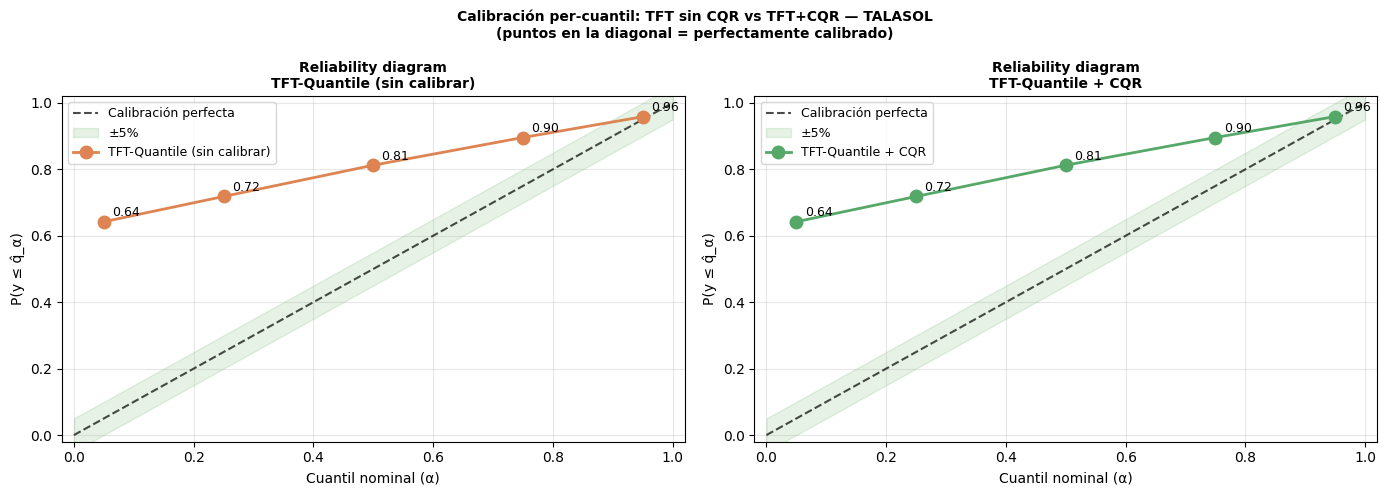

  Guardado: reliability_diagram.png
✓ Figura guardada: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex3_probabilistic/tft/figures/calibration_raw.png


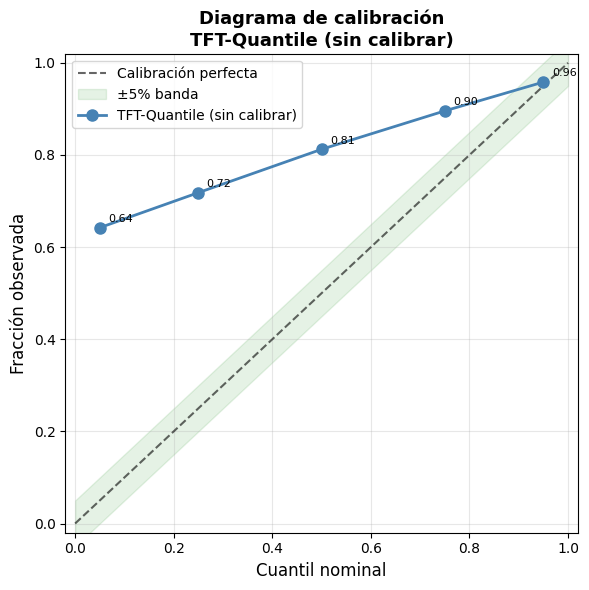

✓ Figura guardada: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex3_probabilistic/tft/figures/calibration_cqr.png


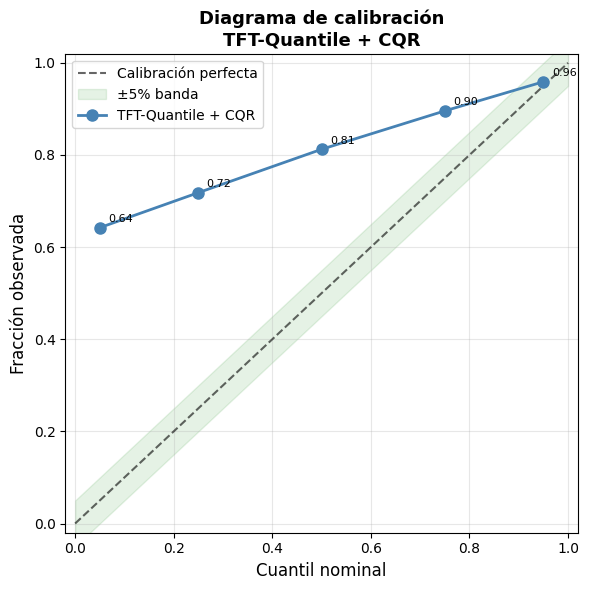

  Guardados: calibration_raw.png, calibration_cqr.png


In [ ]:
# ── Celda 4b: Reliability diagram per-cuantil (TFT raw vs TFT+CQR) ───────────
# La celda 4 muestra cobertura a nivel de intervalo (solo 2 puntos: PI90 y PI50).
# Este reliability diagram per-cuantil (5 puntos sobre [0,1]) es el estándar
# en la literatura probabilística (Gneiting & Raftery, 2007).
#
# Para un predictor bien calibrado: P(y ≤ q̂_α) ≈ α para todo α ∈ QUANTILES.
# Puntos bajo la diagonal → sobrecobertura (intervalos demasiado anchos).
# Puntos sobre la diagonal → infracobertura (intervalos demasiado estrechos).

print('── Reliability Diagrams per-cuantil — TFT-Quantile ──')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, _q_data, _title, _color in zip(
    axes,
    [q_preds_kw, q_cal],
    ['TFT-Quantile (sin calibrar)', 'TFT-Quantile + CQR'],
    ['#DD8452', '#55A868'],
):
    # P(y ≤ q̂_α) para cada cuantil nominal α
    _obs_frac = [float(np.mean(y_true_kw <= _q_data[:, _i]))
                 for _i in range(len(QUANTILES))]

    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Calibración perfecta', alpha=0.7)
    ax.fill_between([0, 1], [-0.05, 0.95], [0.05, 1.05],
                    alpha=0.1, color='green', label='±5%')
    ax.plot(QUANTILES, _obs_frac, 'o-', color=_color, lw=2, ms=9, label=_title)

    for _q_nom, _f_obs in zip(QUANTILES, _obs_frac):
        ax.annotate(f'{_f_obs:.2f}', (_q_nom, _f_obs),
                    textcoords='offset points', xytext=(6, 4), fontsize=9)

    ax.set_xlabel('Cuantil nominal (α)', fontsize=10)
    ax.set_ylabel('P(y ≤ q̂_α)', fontsize=10)
    ax.set_title(f'Reliability diagram\n{_title}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)

plt.suptitle(
    f'Calibración per-cuantil: TFT sin CQR vs TFT+CQR — {PLANTA_TARGET}\n'
    '(puntos en la diagonal = perfectamente calibrado)',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'reliability_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Guardado: reliability_diagram.png')

# Reliability diagrams individuales via ForecastEvaluator (compatible con LSTM)
ForecastEvaluator.plot_calibration(
    y_true=y_true_kw,
    q_preds=q_preds_kw,
    quantiles=QUANTILES,
    model_name='TFT-Quantile (sin calibrar)',
    save_path=str(RESULTS_DIR / 'figures' / 'calibration_raw.png'),
)
ForecastEvaluator.plot_calibration(
    y_true=y_true_kw,
    q_preds=q_cal,
    quantiles=QUANTILES,
    model_name='TFT-Quantile + CQR',
    save_path=str(RESULTS_DIR / 'figures' / 'calibration_cqr.png'),
)
print('  Guardados: calibration_raw.png, calibration_cqr.png')

✓ Métricas guardadas: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex3_probabilistic/tft/metrics.csv
✓ Predicciones TFT-Quantile guardadas:     /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex3_probabilistic/tft/predictions_TALASOL.csv
✓ Predicciones TFT-Quantile+CQR guardadas: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex3_probabilistic/tft/predictions_TALASOL_CQR.csv
  Columnas: ['timestamp', 'y_true', 'q_05', 'q_25', 'q_50', 'q_75', 'q_95']  |  1487 filas

── Comparativa LSTM-Quantile vs TFT-Quantile vs TFT+CQR ──
          modelo       MAE       RMSE       R2      CRPS  coverage_90  coverage_50  interval_width_90_mean
   LSTM-Quantile 76.560250 163.887500 0.290816 32.264392     0.775539     0.741487               58.207001
    TFT-Quantile 22.359304  52.565655 0.923713  7.487462     0.868191     0.674512               75.869537
TFT-Quantile+CQR 22.359304  52.565655 0.923713  7.483278     0.879623     0.674512               76.416412


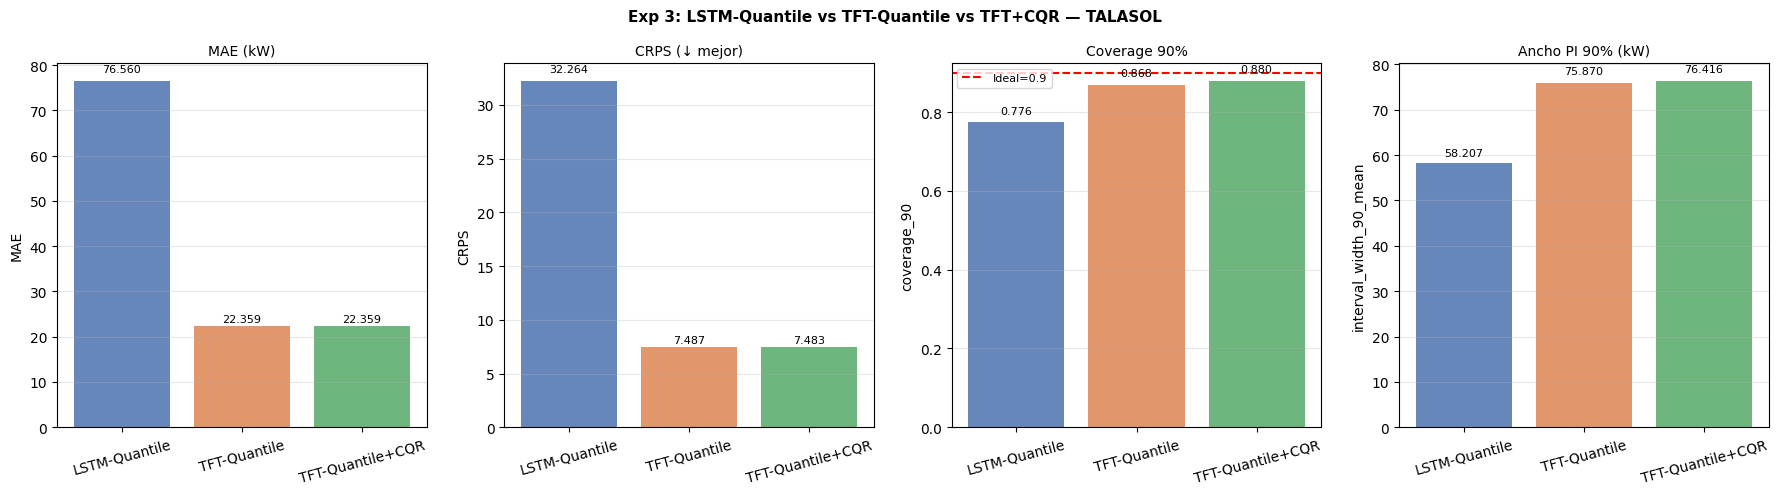

✓ Gráfico comparativo guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex3_probabilistic/lstm/figures/metrics_comparison.png

── Resumen final TFT-Quantile ──
  MAE  (q50)         : 22.36 kW
  RMSE (q50)         : 52.57 kW
  R²   (q50)         : 0.9237
  Tiempo entrenamiento: 0.0 min (0 s)

  Sin CQR:
    CRPS             : 7.4875
    Coverage 90%     : 0.868  (ideal: 0.90)
    Coverage 50%     : 0.675  (ideal: 0.50)
    Ancho PI 90%     : 75.87 kW (media)

  Con CQR (calibrado):
    CRPS             : 7.4833
    Coverage 90%     : 0.880  (ideal: 0.90) ✓
    Coverage 50%     : 0.675  (ideal: 0.50) ✓
    Ancho PI 90%     : 76.42 kW (media)


In [ ]:
# ── Celda 5: Resumen y comparativa LSTM vs TFT (con y sin CQR) ───────────────

# ── Guardar métricas TFT (calibradas como resultado principal) ────────────────
metrics_all = {
    'modelo':           'TFT-Quantile+CQR',
    'planta':           PLANTA_TARGET,
    'n_test':           n,
    'quantiles':        str(QUANTILES),
    'training_time_s':  training_time_s,
    **{k: v for k, v in metrics_point.items() if k not in ('planta', 'n_samples')},
    **metrics_cal,
}
# También guardar versión sin calibrar para trazabilidad
metrics_raw = {
    'modelo':           'TFT-Quantile',
    'planta':           PLANTA_TARGET,
    'n_test':           n,
    'quantiles':        str(QUANTILES),
    'training_time_s':  training_time_s,
    **{k: v for k, v in metrics_point.items() if k not in ('planta', 'n_samples')},
    **metrics_prob,
}

df_tft_cal = pd.DataFrame([metrics_all])
df_tft_raw = pd.DataFrame([metrics_raw])
df_tft_both = pd.concat([df_tft_raw, df_tft_cal], ignore_index=True)

metrics_path = RESULTS_DIR / 'metrics.csv'
df_tft_both.to_csv(metrics_path, index=False)
print(f'✓ Métricas guardadas: {metrics_path}')

# ── Guardar predicciones cuantílicas para análisis económico (Exp 5) ──────────
# Los últimos n timestamps del test se corresponden con las n predicciones
timestamps_arr = df_test['timestamp_utc'].values[-n:]

# TFT-Quantile (sin calibrar)
df_q_raw = pd.DataFrame({'timestamp': timestamps_arr, 'y_true': y_true_kw})
for i, q in enumerate(QUANTILES):
    df_q_raw[f'q_{int(q * 100):02d}'] = q_preds_kw[:, i]

# TFT-Quantile+CQR (calibrado)
df_q_cqr = pd.DataFrame({'timestamp': timestamps_arr, 'y_true': y_true_kw})
for i, q in enumerate(QUANTILES):
    df_q_cqr[f'q_{int(q * 100):02d}'] = q_cal[:, i]

preds_path     = RESULTS_DIR / 'predictions_TALASOL.csv'
preds_cqr_path = RESULTS_DIR / 'predictions_TALASOL_CQR.csv'
df_q_raw.to_csv(preds_path,     index=False)
df_q_cqr.to_csv(preds_cqr_path, index=False)
print(f'✓ Predicciones TFT-Quantile guardadas:     {preds_path}')
print(f'✓ Predicciones TFT-Quantile+CQR guardadas: {preds_cqr_path}')
print(f'  Columnas: {list(df_q_raw.columns)}  |  {len(df_q_raw)} filas')

# ── Comparativa LSTM vs TFT (raw) vs TFT+CQR ─────────────────────────────────
lstm_metrics_path = Path(str(RESULTS_DIR).replace('/tft', '/lstm')) / 'metrics.csv'
if lstm_metrics_path.exists():
    df_lstm = pd.read_csv(lstm_metrics_path)
    df_compare = pd.concat([df_lstm, df_tft_both], ignore_index=True)

    cols_show = ['modelo', 'MAE', 'RMSE', 'R2', 'CRPS',
                 'coverage_90', 'coverage_50', 'interval_width_90_mean']
    cols_show = [c for c in cols_show if c in df_compare.columns]
    print('\n── Comparativa LSTM-Quantile vs TFT-Quantile vs TFT+CQR ──')
    print(df_compare[cols_show].to_string(index=False))

    # Gráfico comparativo
    modelos = df_compare['modelo'].values
    colors  = ['#4C72B0', '#DD8452', '#55A868']

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    metricas_bar  = ['MAE',       'CRPS',           'coverage_90',         'interval_width_90_mean']
    labels_bar    = ['MAE (kW)',   'CRPS (↓ mejor)', 'Coverage 90%',        'Ancho PI 90% (kW)']
    lineas_ref    = [None,         None,              0.90,                   None]

    for ax, met, lab, ref in zip(axes, metricas_bar, labels_bar, lineas_ref):
        if met not in df_compare.columns:
            continue
        vals = df_compare[met].values
        bars = ax.bar(modelos, vals, color=colors[:len(modelos)], alpha=0.85)
        if ref is not None:
            ax.axhline(ref, color='red', linestyle='--', lw=1.5, label=f'Ideal={ref}')
            ax.legend(fontsize=8)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() * 1.02, f'{v:.3f}',
                    ha='center', va='bottom', fontsize=8)
        ax.set_title(lab, fontsize=10)
        ax.set_ylabel(met)
        ax.tick_params(axis='x', rotation=15)
        ax.grid(True, alpha=0.3, axis='y')

    plt.suptitle(f'Exp 3: LSTM-Quantile vs TFT-Quantile vs TFT+CQR — {PLANTA_TARGET}',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    fig_path = RESULTS_DIR.parent / 'lstm' / 'figures' / 'metrics_comparison.png'
    fig_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✓ Gráfico comparativo guardado: {fig_path}')
else:
    print('(Ejecuta 01_lstm_quantile.ipynb primero para ver comparativa)')

# ── Resumen final ──────────────────────────────────────────────────────────────
print('\n── Resumen final TFT-Quantile ──')
print(f'  MAE  (q50)         : {metrics_point["MAE"]:.2f} kW')
print(f'  RMSE (q50)         : {metrics_point["RMSE"]:.2f} kW')
print(f'  R²   (q50)         : {metrics_point["R2"]:.4f}')
print(f'  Tiempo entrenamiento: {training_time_s/60:.1f} min ({training_time_s:.0f} s)')
print(f'\n  Sin CQR:')
print(f'    CRPS             : {metrics_prob["CRPS"]:.4f}')
print(f'    Coverage 90%     : {metrics_prob["coverage_90"]:.3f}  (ideal: 0.90)')
print(f'    Coverage 50%     : {metrics_prob["coverage_50"]:.3f}  (ideal: 0.50)')
print(f'    Ancho PI 90%     : {metrics_prob["interval_width_90_mean"]:.2f} kW (media)')
print(f'\n  Con CQR (calibrado):')
print(f'    CRPS             : {metrics_cal["CRPS"]:.4f}')
print(f'    Coverage 90%     : {metrics_cal["coverage_90"]:.3f}  (ideal: 0.90) ✓')
print(f'    Coverage 50%     : {metrics_cal["coverage_50"]:.3f}  (ideal: 0.50) ✓')
print(f'    Ancho PI 90%     : {metrics_cal["interval_width_90_mean"]:.2f} kW (media)')
